<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/Nhan_dien_benh_phoi_bang_mo_hinh_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

# 1. Kết nối Drive (Nếu bạn chưa kết nối trước đó)
# drive.mount('/content/drive')

# 2. Định nghĩa đường dẫn
base_dir = '/content/drive/MyDrive/CNN/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# 3. Cấu hình ImageDataGenerator (CHỈ RESCALE, KHÔNG AUGMENTATION)
# Chúng ta giữ lại validation_split để chia dữ liệu từ thư mục train
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Chỉ chuẩn hóa pixel về [0, 1]
    validation_split=0.2       # Chia 20% dữ liệu làm Validation
)

# Tập Test chỉ cần rescale
test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Tạo các bộ nạp dữ liệu (Generators)

# Bộ nạp cho tập TRAIN (80% của thư mục train)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
    subset='training',         # Phần training (80%)
    shuffle=True,              # Xáo trộn ảnh để mô hình học khách quan hơn
    seed=123
)

# Bộ nạp cho tập VALIDATION (20% còn lại của thư mục train)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
    subset='validation',       # Phần validation (20%)
    shuffle=True,
    seed=123
)

# Bộ nạp cho tập TEST
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
    shuffle=False              # Không xáo trộn tập test để dễ đánh giá sau này
)

# Kiểm tra kết quả nạp dữ liệu
print("\n--- Thống kê dữ liệu ---")
print("Nhãn của các lớp:", train_generator.class_indices)
print(f"Tổng số ảnh tập Train: {train_generator.samples}")
print(f"Tổng số ảnh tập Validation: {validation_generator.samples}")
print(f"Tổng số ảnh tập Test: {test_generator.samples}")

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

--- Thống kê dữ liệu ---
Nhãn của các lớp: {'NORMAL': 0, 'PNEUMONIA': 1}
Tổng số ảnh tập Train: 4187
Tổng số ảnh tập Validation: 1045
Tổng số ảnh tập Test: 624


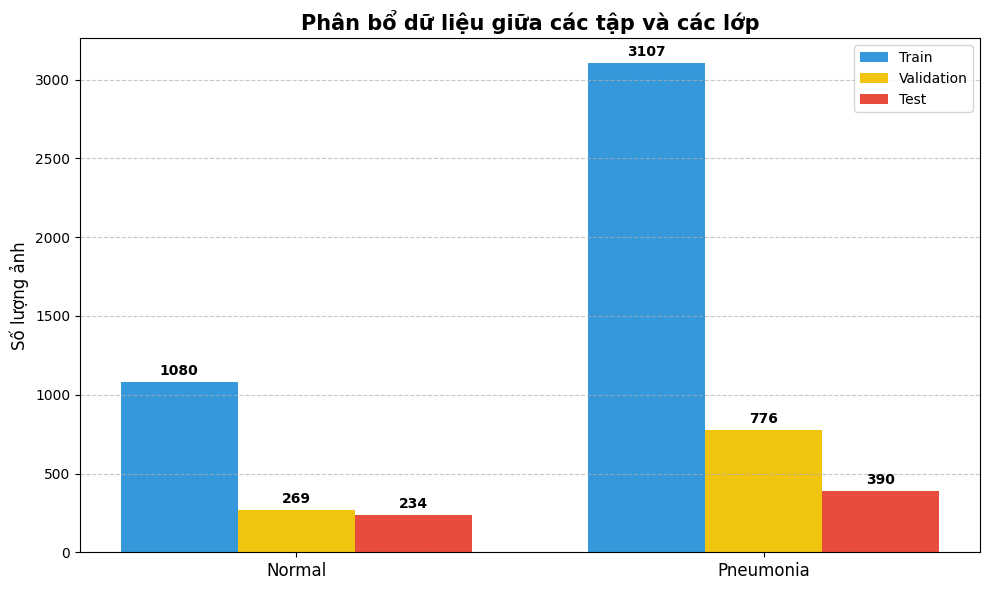

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy số lượng ảnh từ các generator
def get_class_counts(generator):
    classes = generator.classes
    unique, counts = np.unique(classes, return_counts=True)
    # Trả về từ điển {0: count_normal, 1: count_pneumonia}
    return dict(zip(generator.class_indices.keys(), counts))

train_counts = get_class_counts(train_generator)
val_counts = get_class_counts(validation_generator)
test_counts = get_class_counts(test_generator)

# 2. Chuẩn bị dữ liệu để vẽ
labels = ['Normal', 'Pneumonia']
train_vals = [train_counts['NORMAL'], train_counts['PNEUMONIA']]
val_vals = [val_counts['NORMAL'], val_counts['PNEUMONIA']]
test_vals = [test_counts['NORMAL'], test_counts['PNEUMONIA']]

x = np.arange(len(labels))  # Vị trí các nhóm nhãn
width = 0.25  # Độ rộng của cột

# 3. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, train_vals, width, label='Train', color='#3498db')
rects2 = ax.bar(x, val_vals, width, label='Validation', color='#f1c40f')
rects3 = ax.bar(x + width, test_vals, width, label='Test', color='#e74c3c')

# Thêm văn bản, tiêu đề và nhãn
ax.set_ylabel('Số lượng ảnh', fontsize=12)
ax.set_title('Phân bổ dữ liệu giữa các tập và các lớp', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend()

# Hàm tự động ghi số lượng trên đầu mỗi cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from tensorflow.keras import layers, models

# Khởi tạo mô hình tuần tự (Bản gây Overfitting)
model = models.Sequential([
    # Khối 1: Trích xuất các đặc trưng cơ bản (đường nét)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Khối 2: Trích xuất đặc trưng phức tạp hơn
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Khối 3:
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Chuyển đổi dữ liệu từ dạng ảnh sang dạng phẳng (vector)
    layers.Flatten(),

    # Lớp Dense (Fully Connected) để phân loại
    # Việc lược bỏ Dropout ở đây sẽ khiến 512 nơ-ron này dễ dàng "học thuộc lòng" dữ liệu
    layers.Dense(512, activation='relu'),

    # Lớp đầu ra: 1 đầu ra với sigmoid cho phân loại nhị phân
    layers.Dense(1, activation='sigmoid')
])

# Thiết lập thông số huấn luyện
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Cấu hình tên file lưu mô hình
# Bạn nên lưu đuôi .keras (định dạng mới của Keras 3) hoặc .h5
model_path = 'best_model_pneumonia_baseline.keras'

# 2. Thiết lập ModelCheckpoint
# monitor='val_accuracy': Theo dõi độ chính xác trên tập Validation
# save_best_only=True: Chỉ lưu khi kết quả tốt hơn phiên bản cũ
checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# 3. (Tùy chọn) Thiết lập EarlyStopping
# Nếu bạn muốn dừng sớm khi mô hình không còn cải thiện để tránh tốn thời gian
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10, # Sau 10 epoch không giảm loss thì dừng
    restore_best_weights=True
)

# 4. Tiến hành huấn luyện (Train)
print("Bắt đầu huấn luyện mô hình...")
history = model.fit(
    train_generator,
    epochs=30,               # Bạn có thể tăng lên 50 nếu muốn thấy rõ Overfitting hơn
    validation_data=validation_generator,
    callbacks=[checkpoint],  # Gắn "bảo hiểm" lưu mô hình ở đây
    verbose=1
)

# 5. Lưu lại mô hình cuối cùng (để chắc chắn)
model.save('final_model_at_the_end.keras')
print("\n--- HOÀN THÀNH ---")
print(f"Mô hình tốt nhất đã được lưu tại: {model_path}")

Bắt đầu huấn luyện mô hình...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.7238 - loss: 0.8299 
Epoch 1: val_accuracy improved from None to 0.96938, saving model to best_model_pneumonia_baseline.keras

Epoch 1: finished saving model to best_model_pneumonia_baseline.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1308s 20s/step - accuracy: 0.8283 - loss: 0.4416 - val_accuracy: 0.9694 - val_loss: 0.1029
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.9571 - loss: 0.1337
Epoch 2: val_accuracy did not improve from 0.96938
66/66 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9534 - loss: 0.1378 - val_accuracy: 0.9675 - val_loss: 0.0919
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9679 - loss: 0.0892
Epoch 3: val_accuracy improved from 0.96938 to 0.97416, saving model to best_model_pneumonia_baseline.keras

Epoch 3: finished saving model to best_model_pneumonia_baseline.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9682 - loss: 0.0915 -

In [ ]:
from google.colab import files
files.download('best_model_pneumonia_baseline.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

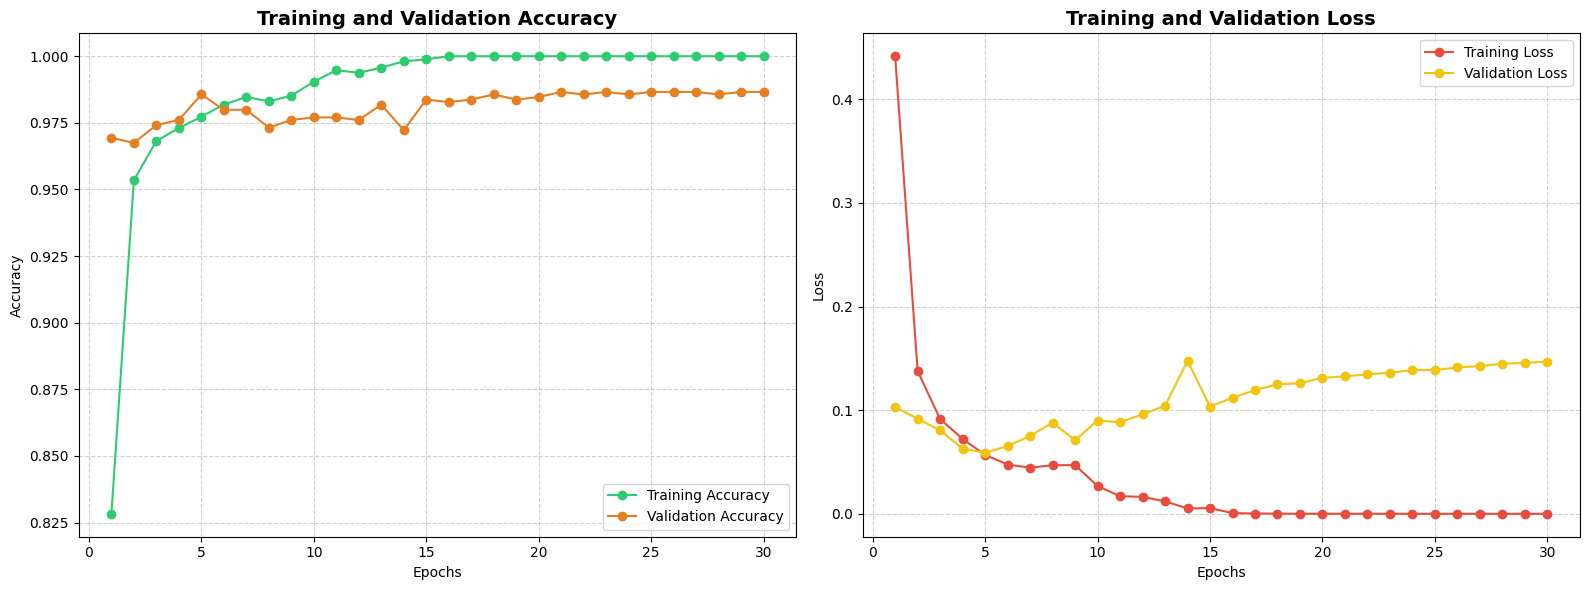

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ biến history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Thiết lập kích thước khung hình
plt.figure(figsize=(16, 6))

# 1. Vẽ biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='#2ecc71')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='#e67e22')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='#e74c3c')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='#f1c40f')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Found 1045 images belonging to 2 classes.
Đang tiến hành dự đoán...
33/33 ━━━━━━━━━━━━━━━━━━━━ 14s 387ms/step


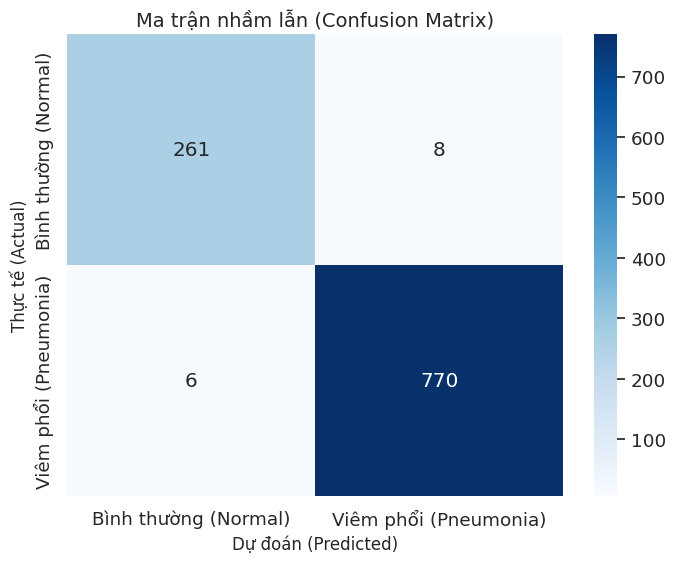


--- Báo cáo phân loại chi tiết ---
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.97       269
   Pneumonia       0.99      0.99      0.99       776

    accuracy                           0.99      1045
   macro avg       0.98      0.98      0.98      1045
weighted avg       0.99      0.99      0.99      1045



In [ ]:
# Ma trận nhầm lẫn trên tập Val
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# BƯỚC 1: Tạo một generator riêng để kiểm tra (tắt shuffle để nhãn khớp với ảnh)
# Thay 'path_to_train_data' bằng biến chứa đường dẫn thư mục train của bạn
eval_generator = train_datagen.flow_from_directory(
    train_dir,                # Thư mục chứa dữ liệu
    target_size=(150, 150),   # Phải khớp với lúc train
    batch_size=32,
    class_mode='binary',
    subset='validation',      # Lấy đúng tập validation
    shuffle=False             # QUAN TRỌNG: Không xáo trộn để lấy đúng nhãn y_true
)

# BƯỚC 2: Dự đoán
print("Đang tiến hành dự đoán...")
y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_generator.classes

# BƯỚC 3: Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'],
            yticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

# BƯỚC 4: In báo cáo chi tiết Precision, Recall, F1-score
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

10/10 ━━━━━━━━━━━━━━━━━━━━ 121s 13s/step


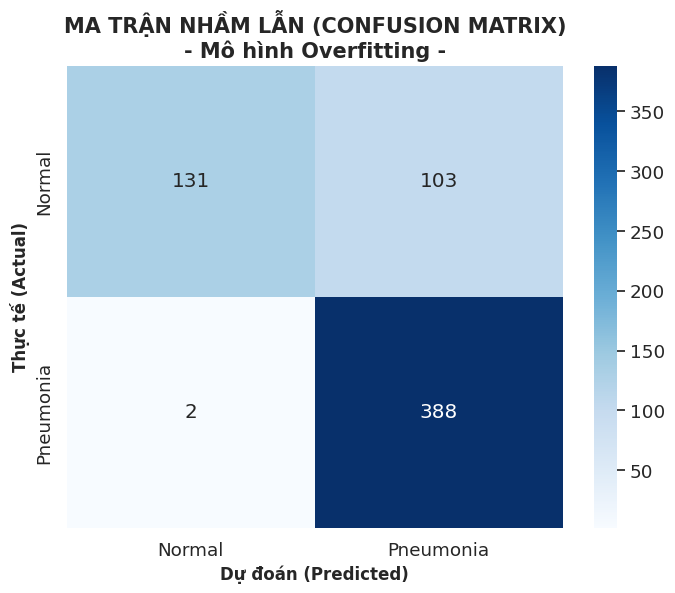


--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

      Normal       0.98      0.56      0.71       234
   Pneumonia       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



In [ ]:
# Ma trận nhầm lẫn trên tập tests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Dự đoán trên tập Test
# Đảm bảo shuffle=False trong test_generator để nhãn khớp với dự đoán
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

# 2. Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)
class_names = ['Normal', 'Pneumonia']

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2) # Điều chỉnh cỡ chữ
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX)\n- Mô hình Overfitting -', fontsize=15, fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Dự đoán (Predicted)', fontsize=12, fontweight='bold')
plt.show()

# 4. In báo cáo chi tiết (Precision, Recall, F1-score)
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
#CẢI TIẾN MÔ HÌNH BẰNG CÁCH LÀM GIÀU DỮ LIỆU TRÊN TẬP TRAIN VÀ SỬ DỤNG DROPOUT ĐỂ NGĂN CHẶN OVERFITING


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

# 2. Định nghĩa đường dẫn (Hãy thay đổi tên folder cho đúng với Drive của bạn)
# Giả sử folder 'chest_xray' nằm ngay ngoài cùng của My Drive
base_dir = '/content/drive/MyDrive/CNN/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# 3. Cấu hình ImageDataGenerator với validation_split
# Chúng ta sẽ thực hiện Augmentation (tăng cường dữ liệu) cho tập Train
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Chuẩn hóa pixel về [0, 1]
    validation_split=0.2,      # QUAN TRỌNG: Chia 20% dữ liệu để làm Validation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Tập Test chỉ cần rescale, không cần split hay augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# 4. Tạo các bộ nạp dữ liệu (Generators)

# Bộ nạp cho tập TRAIN (80% của thư mục train)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
    subset='training',         # Xác định đây là phần training (80%)
    seed=123                   # Giữ seed cố định để việc chia file không bị xáo trộn mỗi lần chạy
)

# Bộ nạp cho tập VALIDATION (20% còn lại của thư mục train)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary',
    subset='validation',       # Xác định đây là phần validation (20%)
    seed=123
)

# Bộ nạp cho tập TEST (Giữ nguyên từ thư mục test)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=64,
    class_mode='binary'
)

# Kiểm tra nhãn lớp
print("Nhãn của các lớp:", train_generator.class_indices)

Found 4187 images belonging to 2 classes.
Found 1045 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Nhãn của các lớp: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras import layers, models

# Khởi tạo mô hình tuần tự
model = models.Sequential([
    # Khối 1: Trích xuất các đặc trưng cơ bản (đường nét)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    # Khối 2: Trích xuất đặc trưng phức tạp hơn
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Khối 3:
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Chuyển đổi dữ liệu từ dạng ảnh sang dạng phẳng (vector)
    layers.Flatten(),

    # Lớp Dense (Fully Connected) để phân loại
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Chống học vẹt (overfitting)
    layers.Dense(1, activation='sigmoid') # 1 đầu ra: 0 (Normal) hoặc 1 (Pneumonia)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras import optimizers

# 1. Khai báo siêu tham số (Hyper-parameters)
LR = 0.001          # Tỷ lệ học (Learning Rate)
BATCH_SIZE = 64     # Số lượng mẫu dữ liệu trong một lần cập nhật trọng số
EPOCHS = 30         # Tổng số vòng lặp huấn luyện
OPTIMIZER = optimizers.Adam(learning_rate=LR)
LOSS_FUNCTION = 'binary_crossentropy'

# 2. Biên dịch mô hình (Compile)
model.compile(
    optimizer=OPTIMIZER,
    loss=LOSS_FUNCTION,
    metrics=['accuracy']
)

print("Đã cấu hình xong siêu tham số. Sẵn sàng huấn luyện!")

Đã cấu hình xong siêu tham số. Sẵn sàng huấn luyện!


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Thiết lập nơi lưu và điều kiện lưu
# File .keras là định dạng mới, tối ưu hơn .h5 cho TensorFlow 2.x/3.x
checkpoint_path = "best_model_chest_xray.keras"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy', # Theo dõi độ chính xác trên tập Validation
    save_best_only=True,    # Chỉ lưu nếu epoch sau tốt hơn epoch trước
    mode='max',             # Lưu khi accuracy đạt cực đại
    verbose=1               # In thông báo mỗi khi lưu thành công
)

# 2. Huấn luyện với callback
history = model.fit(
    train_generator,
    epochs=30, # Hoặc sử dụng biến EPOCHS của bạn
    validation_data=validation_generator,
    callbacks=[checkpoint_callback] # Thêm callback vào đây
)

# 3. Lưu lại mô hình cuối cùng sau khi chạy hết các epoch (để dự phòng)
model.save("final_model_complete.keras")

print(f"--- Hoàn thành! Mô hình tốt nhất đã được lưu tại: {checkpoint_path} ---")

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7425 - loss: 0.6040
Epoch 1: val_accuracy improved from None to 0.88708, saving model to best_model_chest_xray.keras

Epoch 1: finished saving model to best_model_chest_xray.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 558s 8s/step - accuracy: 0.8128 - loss: 0.4359 - val_accuracy: 0.8871 - val_loss: 0.2461
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8799 - loss: 0.2660
Epoch 2: val_accuracy did not improve from 0.88708
66/66 ━━━━━━━━━━━━━━━━━━━━ 353s 5s/step - accuracy: 0.8887 - loss: 0.2531 - val_accuracy: 0.8823 - val_loss: 0.2672
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8990 - loss: 0.2384
Epoch 3: val_accuracy improved from 0.88708 to 0.93780, saving model to best_model_chest_xray.keras

Epoch 3: finished saving model to best_model_chest_xray.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.9054 - loss: 0.2341 - val_accuracy: 0.9378 - val_loss: 0.1717
Epoch 4/30
66/66 ━━━━━━━━━━━━

In [8]:
from google.colab import files
files.download('final_model_complete.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

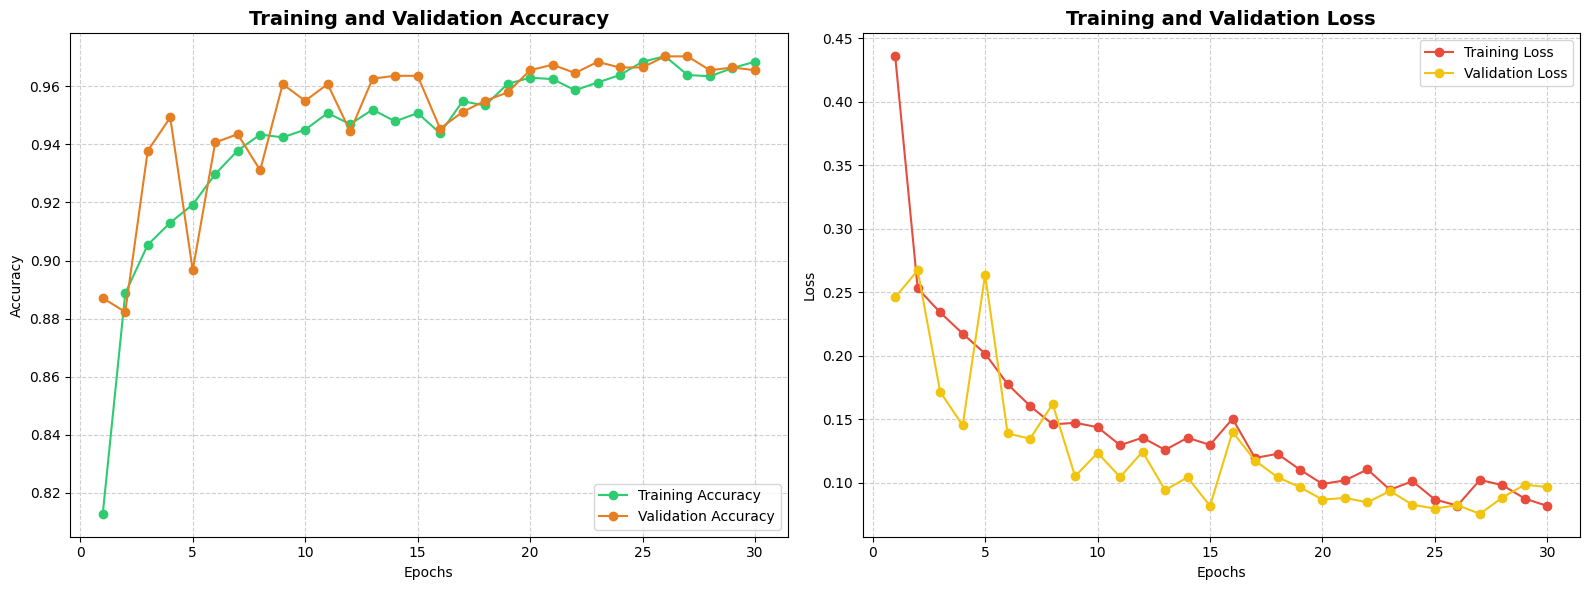

In [9]:
# Vẽ biểu đồ mô hình cải tiến
import matplotlib.pyplot as plt

# Lấy dữ liệu từ biến history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Thiết lập kích thước khung hình
plt.figure(figsize=(16, 6))

# 1. Vẽ biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='#2ecc71')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='#e67e22')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='#e74c3c')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='#f1c40f')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Found 1045 images belonging to 2 classes.
Đang tiến hành dự đoán trên tập Validation...


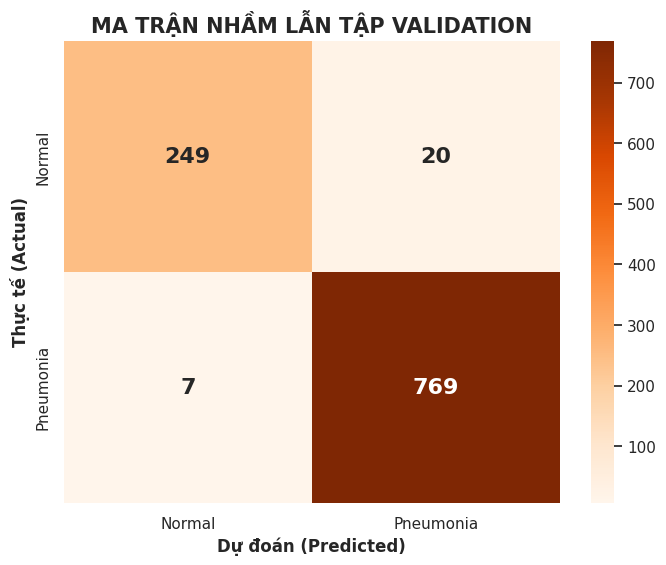


--- BÁO CÁO PHÂN LOẠI CHI TIẾT (TẬP VAL) ---
              precision    recall  f1-score   support

      Normal       0.97      0.93      0.95       269
   Pneumonia       0.97      0.99      0.98       776

    accuracy                           0.97      1045
   macro avg       0.97      0.96      0.97      1045
weighted avg       0.97      0.97      0.97      1045



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# BƯỚC 1: Khởi tạo Generator (Giữ nguyên cấu hình của bạn)
eval_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# BƯỚC 2: Dự đoán theo cơ chế an toàn (Khớp ảnh và nhãn 100%)
eval_generator.reset() # Đưa con trỏ về đầu
y_true_val = []
y_pred_probs_val = []

print("Đang tiến hành dự đoán trên tập Validation...")
for i in range(len(eval_generator)):
    x_batch, y_batch = next(eval_generator)
    preds = model.predict(x_batch, verbose=0)

    y_true_val.extend(y_batch)       # Lấy nhãn thật từ batch
    y_pred_probs_val.extend(preds)   # Lấy dự đoán từ batch

y_true_val = np.array(y_true_val)
y_pred_val = (np.array(y_pred_probs_val) > 0.5).astype(int).flatten()

# BƯỚC 3: Vẽ Ma trận nhầm lẫn
cm_val = confusion_matrix(y_true_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', # Đổi màu cam cho dễ phân biệt với tập Test
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('MA TRẬN NHẦM LẪN TẬP VALIDATION', fontsize=15, fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontweight='bold')
plt.xlabel('Dự đoán (Predicted)', fontweight='bold')
plt.show()

# BƯỚC 4: In báo cáo
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT (TẬP VAL) ---")
print(classification_report(y_true_val, y_pred_val, target_names=['Normal', 'Pneumonia']))

Đang tiến hành dự đoán trên tập Test...


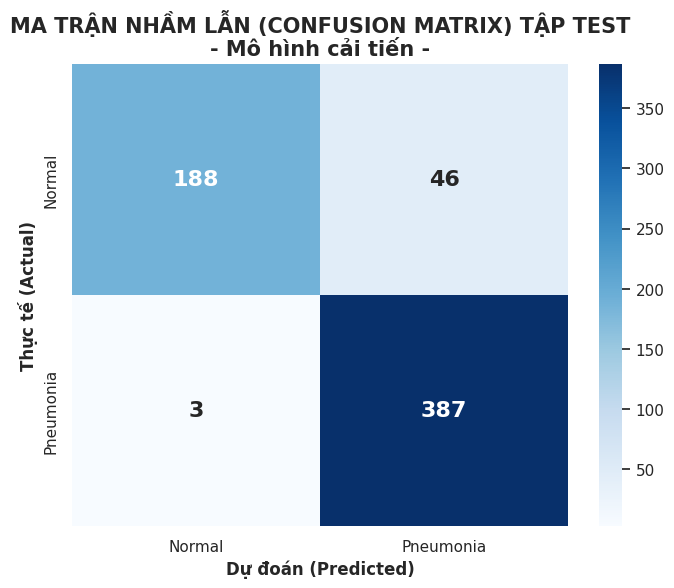

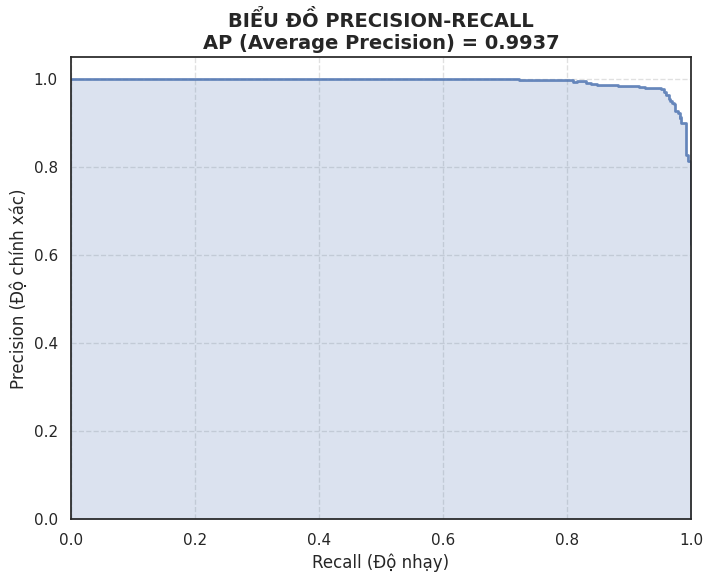


BÁO CÁO PHÂN LOẠI CHI TIẾT
              precision    recall  f1-score   support

      Normal       0.98      0.80      0.88       234
   Pneumonia       0.89      0.99      0.94       390

    accuracy                           0.92       624
   macro avg       0.94      0.90      0.91       624
weighted avg       0.93      0.92      0.92       624



In [15]:
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score

# --- 1. CHUẨN BỊ DỮ LIỆU DỰ ĐOÁN ---
print("Đang tiến hành dự đoán trên tập Test...")
test_generator.reset()

y_true = []
y_pred_probs = []

# Duyệt qua từng batch của tập test để đảm bảo nhãn và ảnh khớp nhau 100%
for i in range(len(test_generator)):
    x_batch, y_batch = next(test_generator)
    preds = model.predict(x_batch, verbose=0)

    y_true.extend(y_batch)          # Lưu nhãn thật
    y_pred_probs.extend(preds)      # Lưu xác suất dự đoán

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

class_names = ['Normal', 'Pneumonia']

# --- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.set(style="white")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 16, "weight": "bold"})

plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TẬP TEST\n- Mô hình cải tiến -', fontsize=15, fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontsize=12, fontweight='bold')
plt.xlabel('Dự đoán (Predicted)', fontsize=12, fontweight='bold')
plt.show()

# --- 3. VẼ BIỂU ĐỒ PRECISION-RECALL (PR CURVE) ---
precision, recall, _ = precision_recall_curve(y_true, y_pred_probs)
ap_score = average_precision_score(y_true, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.8, where='post', linewidth=2)
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Độ nhạy)')
plt.ylabel('Precision (Độ chính xác)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title(f'BIỂU ĐỒ PRECISION-RECALL\nAP (Average Precision) = {ap_score:.4f}', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 4. IN BÁO CÁO CHI TIẾT ---
print("\n" + "="*30)
print("BÁO CÁO PHÂN LOẠI CHI TIẾT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


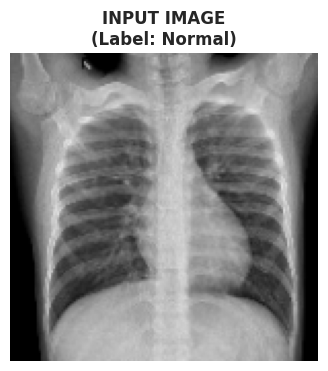

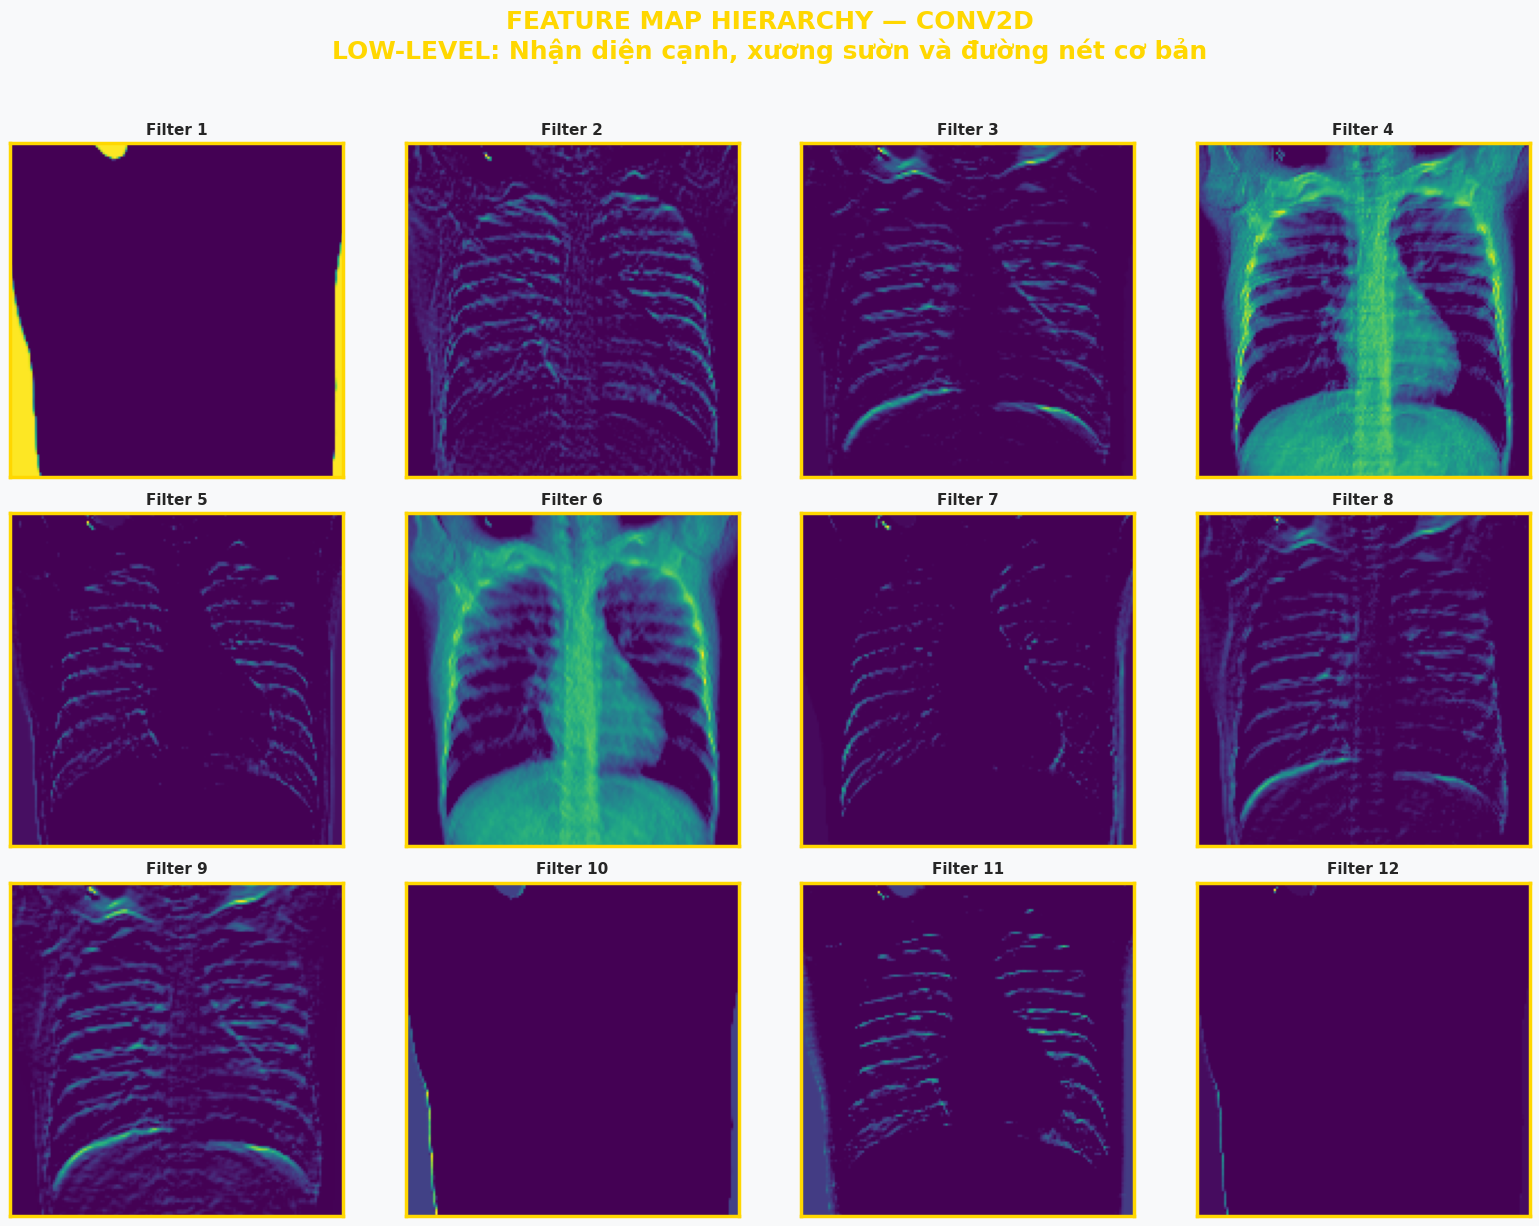

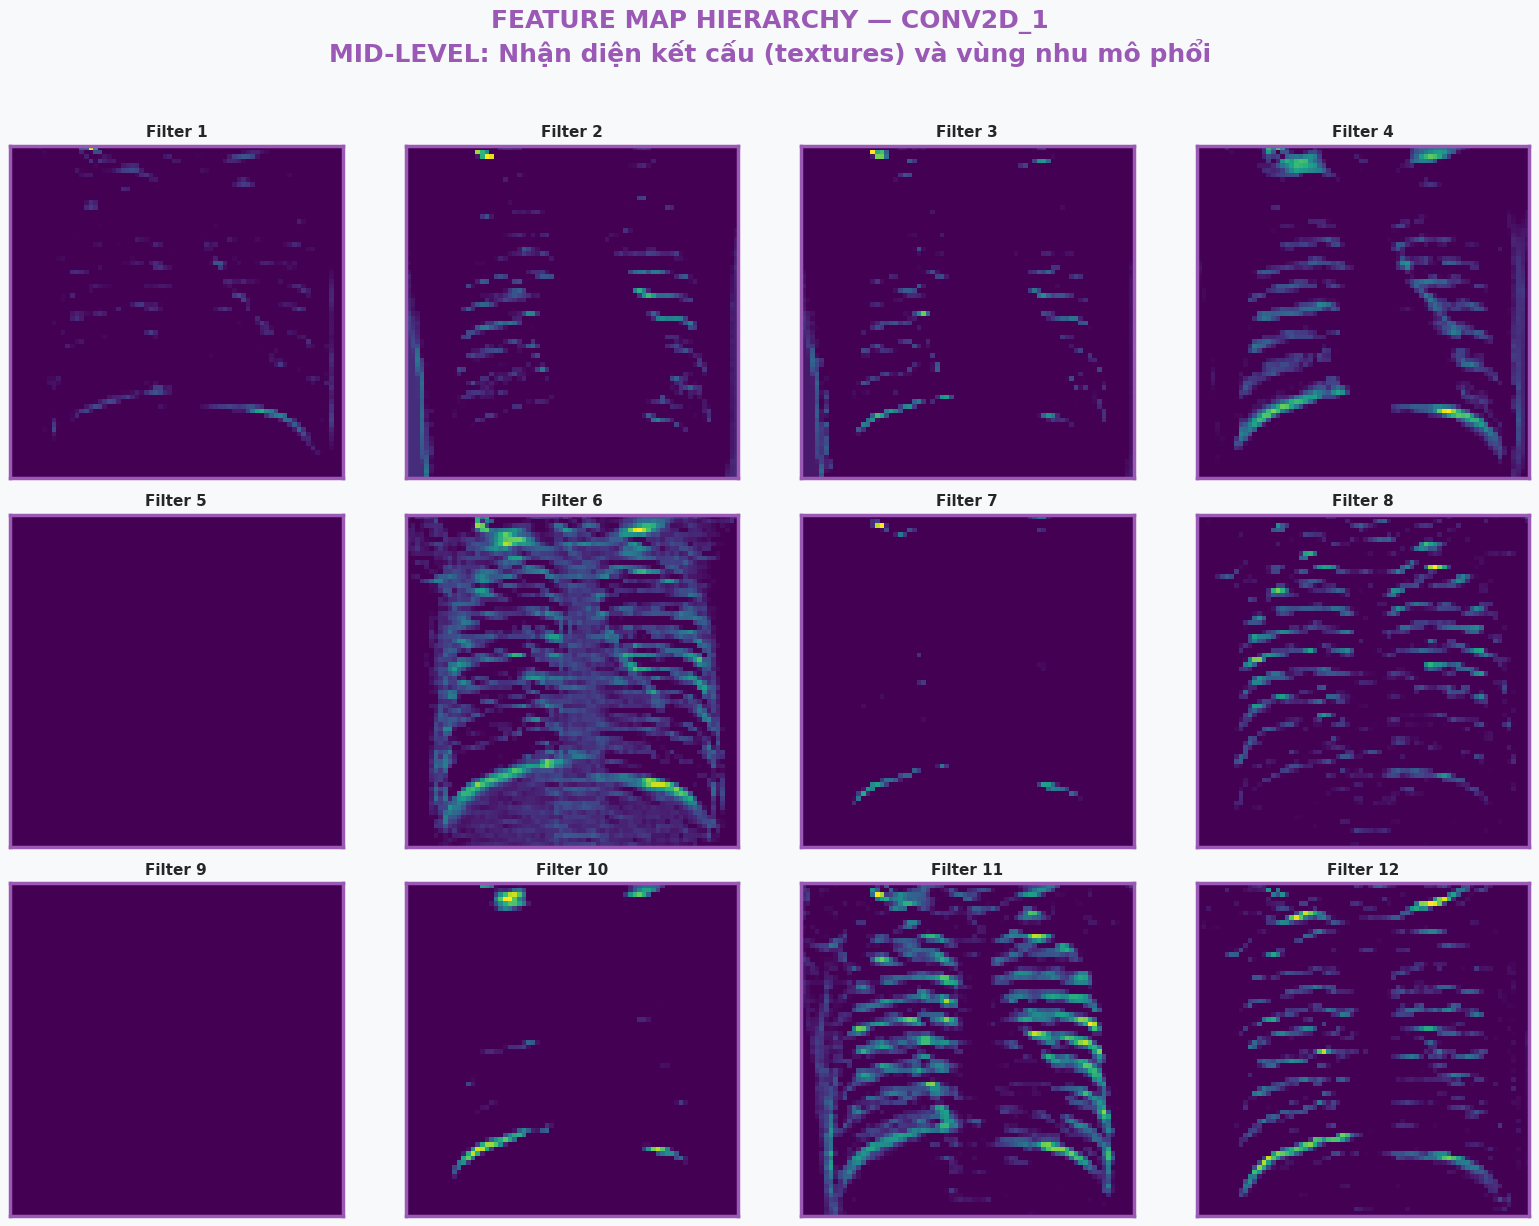

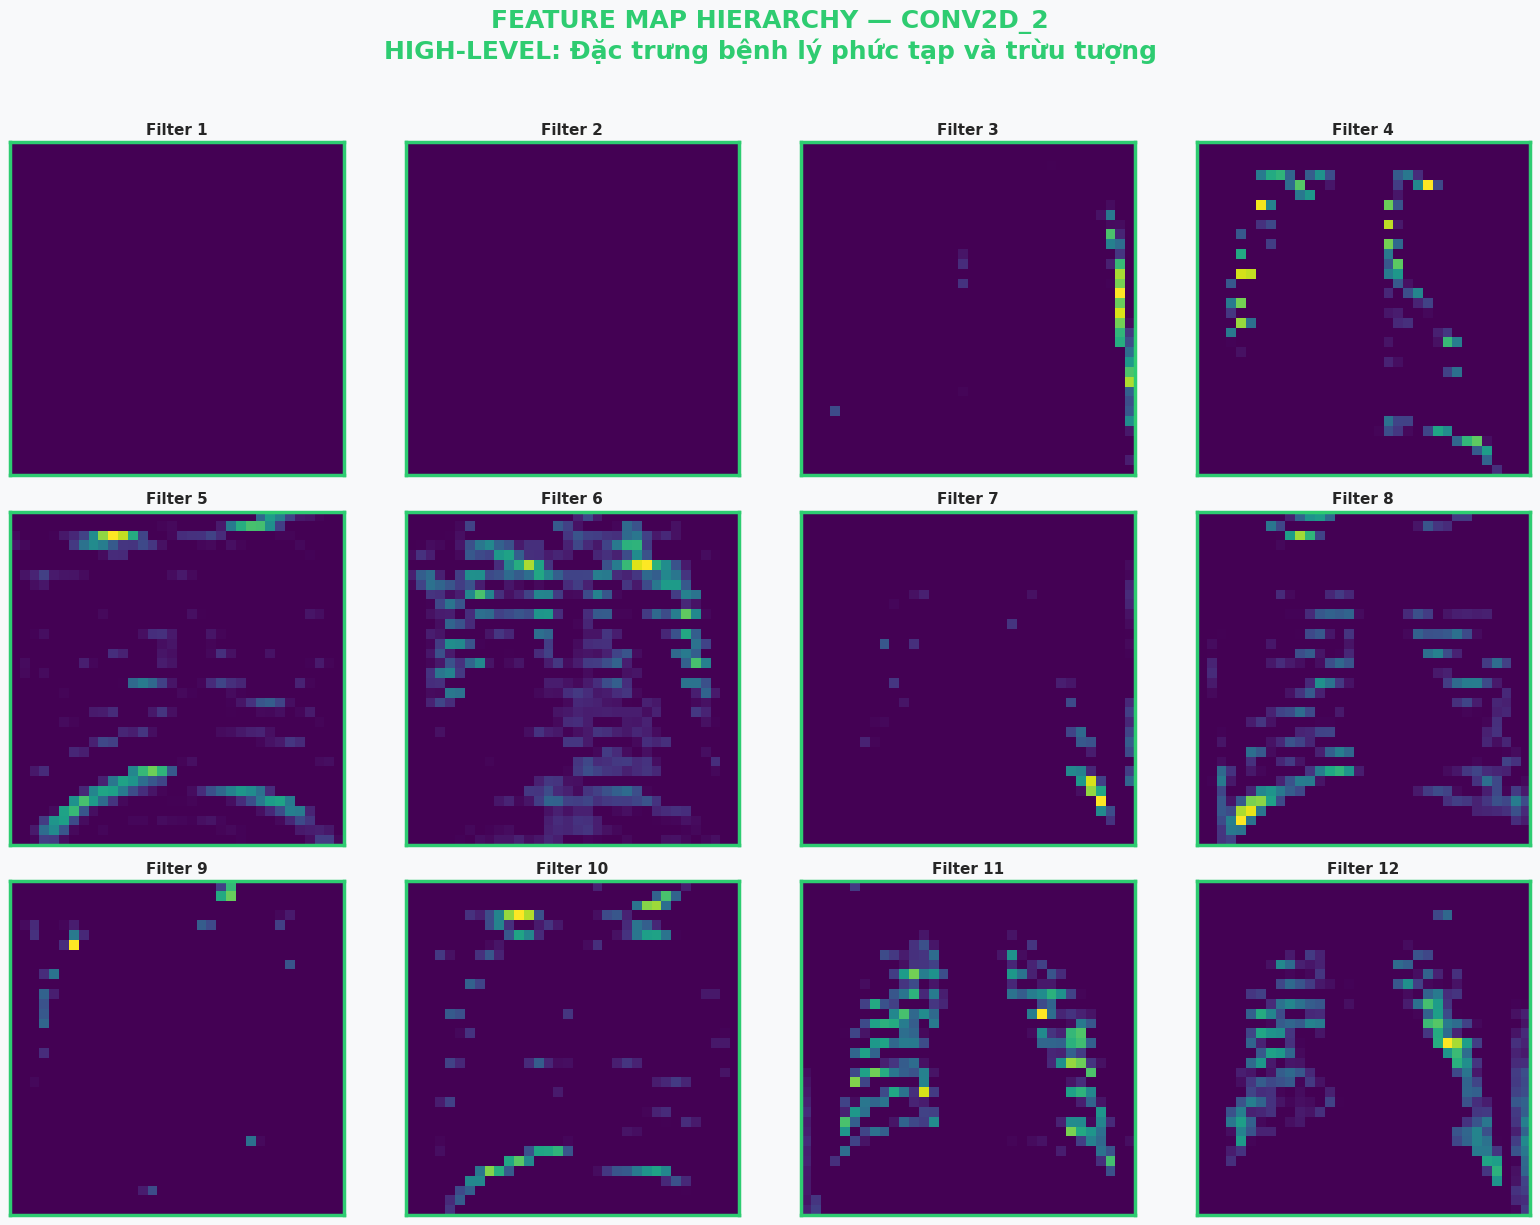

In [16]:
#Hiển thị đặc trưng
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
# Đảm bảo lấy ảnh từ tập Validation để quan sát cách mạng "tư duy" trên dữ liệu lạ
eval_generator.reset()
img_batch, label_batch = next(eval_generator)
sample_img = img_batch[0]
img_tensor = np.expand_dims(sample_img, axis=0)

# --- BƯỚC 2: XÂY DỰNG MÔ HÌNH PHỤ ---
# Cách này giúp lấy output của từng lớp Conv2D mà không bị lỗi tensor
input_shape = (150, 150, 3)
new_input = Input(shape=input_shape)
x = new_input
layer_outputs = []
conv_layer_names = []

for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name.lower():
        layer_outputs.append(x)
        conv_layer_names.append(layer.name)

visualization_model = Model(inputs=new_input, outputs=layer_outputs)

# --- BƯỚC 3: TRÍCH XUẤT ĐẶC TRƯNG (FEATURE MAPS) ---
feature_maps = visualization_model.predict(img_tensor)

# --- BƯỚC 4: HÀM VẼ TRỰC QUAN HÓA CHUYÊN NGHIỆP ---
def plot_final_feature_maps(fmaps, names, max_maps=12):
    # Cấu hình màu sắc và chú thích phân cấp theo tầng mạng CNN
    colors = ['#FFD700', '#9B59B6', '#2ECC71', '#E74C3C'] # Vàng, Tím, Xanh lá, Đỏ
    descriptions = [
        "LOW-LEVEL: Nhận diện cạnh, xương sườn và đường nét cơ bản",
        "MID-LEVEL: Nhận diện kết cấu (textures) và vùng nhu mô phổi",
        "HIGH-LEVEL: Đặc trưng bệnh lý phức tạp và trừu tượng",
        "DEEP-LEVEL: Các tín hiệu quyết định phân loại cuối cùng"
    ]

    for i, (fmap, name) in enumerate(zip(fmaps, names)):
        # Giới hạn số lượng bản đồ hiển thị để tránh bị rối (mặc định 12)
        n_features = min(fmap.shape[-1], max_maps)
        cols = 4
        rows = int(np.ceil(n_features / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
        fig.patch.set_facecolor('#F8F9FA') # Màu nền xám nhạt chuyên nghiệp

        # Lấy mô tả tương ứng, nếu hết danh sách thì dùng mô tả mặc định
        current_desc = descriptions[i] if i < len(descriptions) else "Tầng đặc trưng sâu"
        current_color = colors[i % len(colors)]

        plt.suptitle(f"FEATURE MAP HIERARCHY — {name.upper()}\n{current_desc}",
                     fontsize=18, fontweight='bold', color=current_color, y=1.02)

        for j in range(rows * cols):
            if rows > 1:
                ax = axes[j // cols, j % cols]
            else:
                ax = axes[j]

            if j < n_features:
                fm = fmap[0, :, :, j]
                # Chuẩn hóa (Normalize) để hiển thị rõ các vùng kích hoạt
                fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

                im = ax.imshow(fm, cmap='viridis') # Viridis giúp phân biệt cường độ tốt nhất
                ax.set_title(f"Filter {j+1}", fontsize=11, fontweight='bold')

                # Thêm khung viền màu sắc tương ứng với tầng
                for spine in ax.spines.values():
                    spine.set_edgecolor(current_color)
                    spine.set_linewidth(2.5)
            else:
                ax.axis('off')

            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()
        plt.show()

# --- BƯỚC 5: THỰC THI ---
# Hiển thị ảnh gốc để đối chiếu
plt.figure(figsize=(4, 4))
# Nếu ảnh đã bị rescaling (1/255), imshow vẫn hoạt động tốt
plt.imshow(sample_img)
plt.title(f"INPUT IMAGE\n(Label: {'Pneumonia' if label_batch[0] == 1 else 'Normal'})", fontweight='bold')
plt.axis('off')
plt.show()

# Xuất bản đồ đặc trưng
plot_final_feature_maps(feature_maps, conv_layer_names)

In [ ]:
# Huấn luyện cải tiến 2
history = model.fit(
    train_generator,
    epochs=EPOCHS, # Sử dụng biến EPOCHS đã khai báo ở trên
    validation_data=validation_generator
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 776s 6s/step - accuracy: 0.8042 - loss: 0.4516 - val_accuracy: 0.8651 - val_loss: 0.3051
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 359s 3s/step - accuracy: 0.8894 - loss: 0.2586 - val_accuracy: 0.9340 - val_loss: 0.1702
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 353s 3s/step - accuracy: 0.8901 - loss: 0.2682 - val_accuracy: 0.9014 - val_loss: 0.2356
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 352s 3s/step - accuracy: 0.9042 - loss: 0.2256 - val_accuracy: 0.9359 - val_loss: 0.1606
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.9198 - loss: 0.2042 - val_accuracy: 0.9368 - val_loss: 0.1467
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.9190 - loss: 0.2024 - val_accuracy: 0.9435 - val_loss: 0.1506
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 357s 3s/step - accuracy: 0.9334 - loss: 0.1840 - val_accuracy: 0.9455 - val_loss: 0.1367
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.9372 - loss: 0.1643 - val_accu

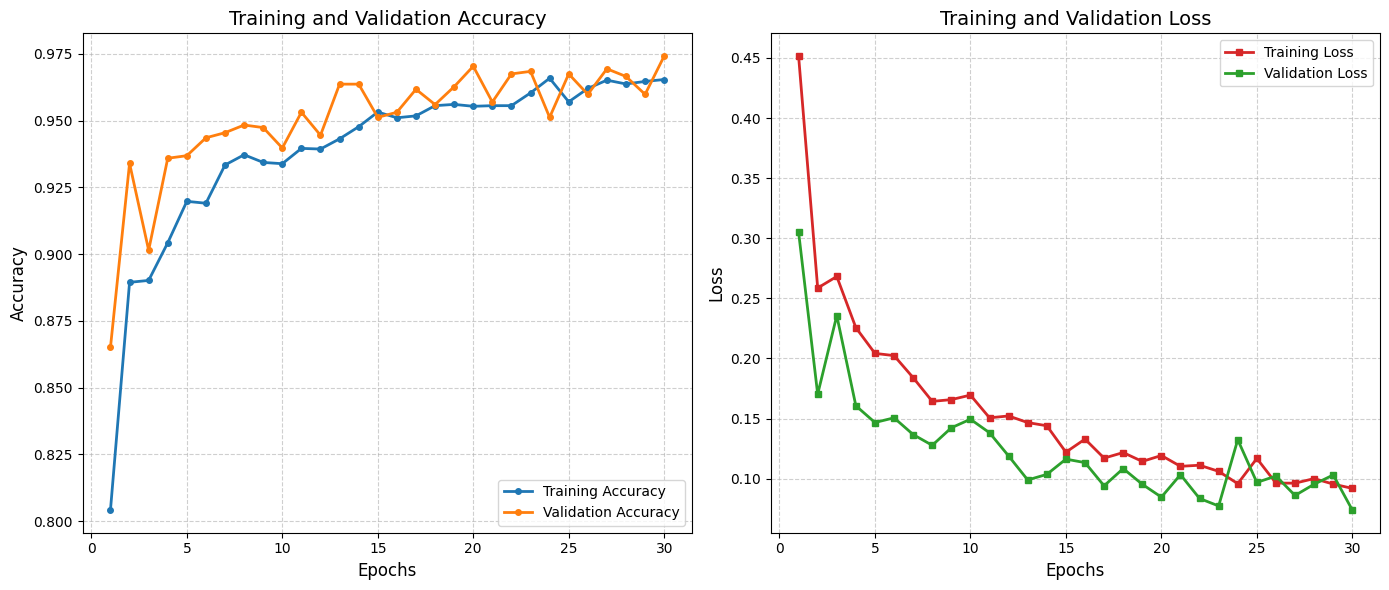

In [ ]:
import matplotlib.pyplot as plt

# Trích xuất dữ liệu từ biến history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Khởi tạo khung hình
plt.figure(figsize=(14, 6))

# --- Biểu đồ Accuracy (Độ chính xác) ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, marker='o', markersize=4)
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# --- Biểu đồ Loss (Sai số) ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', linewidth=2, marker='s', markersize=4)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2ca02c', linewidth=2, marker='s', markersize=4)
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('ket_qua_huan_luyen.png', dpi=300)
plt.show()

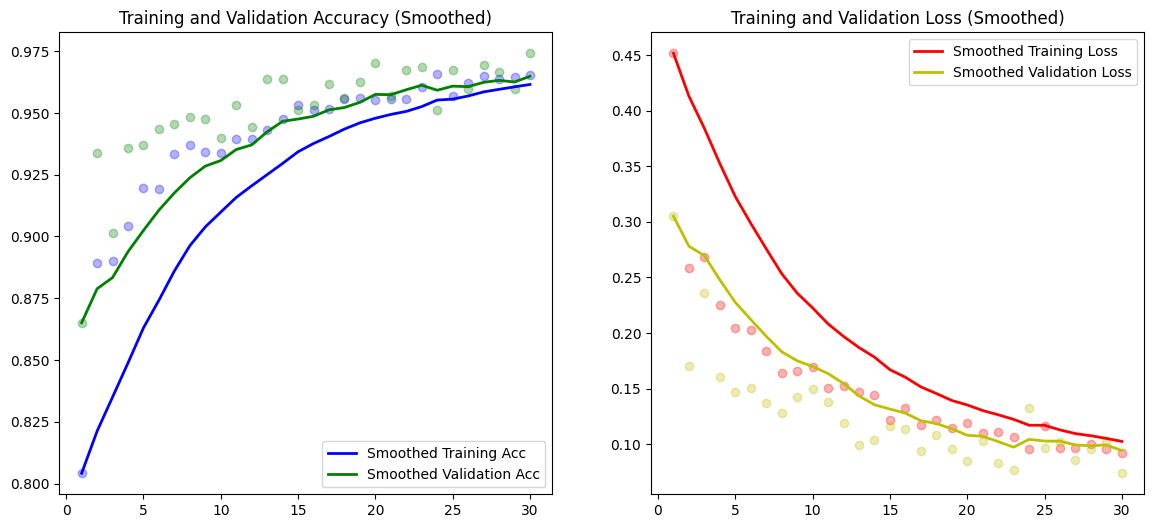

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Lấy dữ liệu
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
# Vẽ đường gốc (mờ)
plt.plot(epochs, acc, 'bo', alpha=0.3)
plt.plot(epochs, val_acc, 'go', alpha=0.3)
# Vẽ đường đã làm mượt (đậm)
plt.plot(epochs, smooth_curve(acc), 'b', label='Smoothed Training Acc', linewidth=2)
plt.plot(epochs, smooth_curve(val_acc), 'g', label='Smoothed Validation Acc', linewidth=2)
plt.title('Training and Validation Accuracy (Smoothed)')
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
# Vẽ đường gốc (mờ)
plt.plot(epochs, loss, 'ro', alpha=0.3)
plt.plot(epochs, val_loss, 'yo', alpha=0.3)
# Vẽ đường đã làm mượt (đậm)
plt.plot(epochs, smooth_curve(loss), 'r', label='Smoothed Training Loss', linewidth=2)
plt.plot(epochs, smooth_curve(val_loss), 'y', label='Smoothed Validation Loss', linewidth=2)
plt.title('Training and Validation Loss (Smoothed)')
plt.legend()

plt.show()

Found 1045 images belonging to 2 classes.
Đang tiến hành dự đoán...
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


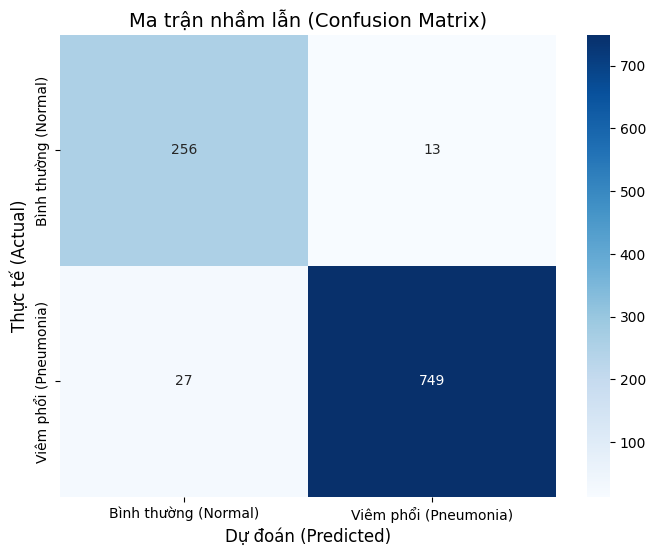


--- Báo cáo phân loại chi tiết ---
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.93       269
   Pneumonia       0.98      0.97      0.97       776

    accuracy                           0.96      1045
   macro avg       0.94      0.96      0.95      1045
weighted avg       0.96      0.96      0.96      1045



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# BƯỚC 1: Tạo một generator riêng để kiểm tra (tắt shuffle để nhãn khớp với ảnh)
# Thay 'path_to_train_data' bằng biến chứa đường dẫn thư mục train của bạn
eval_generator = train_datagen.flow_from_directory(
    train_dir,                # Thư mục chứa dữ liệu
    target_size=(150, 150),   # Phải khớp với lúc train
    batch_size=32,
    class_mode='binary',
    subset='validation',      # Lấy đúng tập validation
    shuffle=False             # QUAN TRỌNG: Không xáo trộn để lấy đúng nhãn y_true
)

# BƯỚC 2: Dự đoán
print("Đang tiến hành dự đoán...")
y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_generator.classes

# BƯỚC 3: Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'],
            yticklabels=['Bình thường (Normal)', 'Viêm phổi (Pneumonia)'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14)
plt.ylabel('Thực tế (Actual)', fontsize=12)
plt.xlabel('Dự đoán (Predicted)', fontsize=12)
plt.show()

# BƯỚC 4: In báo cáo chi tiết Precision, Recall, F1-score
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

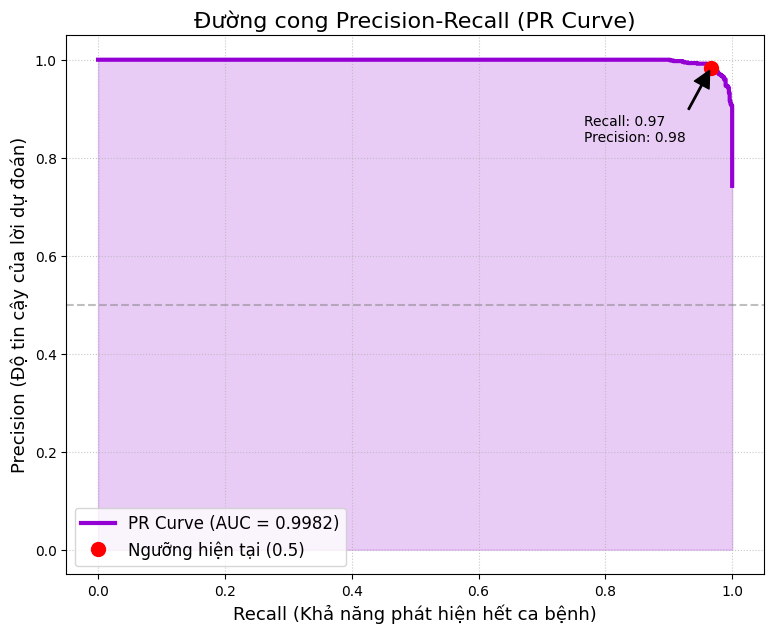

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Giả sử bạn đã có y_true và y_pred_probs từ bước dự đoán trước đó
# Tính toán các giá trị Precision và Recall ứng với các ngưỡng (thresholds) khác nhau
precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(9, 7))

# Vẽ đường cong PR
plt.plot(recall, precision, color='darkviolet', lw=3, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.fill_between(recall, precision, alpha=0.2, color='darkviolet')

# Đánh dấu điểm Threshold 0.5 (điểm mà bạn đang dùng cho Confusion Matrix)
# Tìm vị trí gần ngưỡng 0.5 nhất trong mảng thresholds
idx = (np.abs(thresholds - 0.5)).argmin()
plt.plot(recall[idx], precision[idx], 'ro', markersize=10, label=f'Ngưỡng hiện tại (0.5)')

# Trang trí biểu đồ
plt.title('Đường cong Precision-Recall (PR Curve)', fontsize=16)
plt.xlabel('Recall (Khả năng phát hiện hết ca bệnh)', fontsize=13)
plt.ylabel('Precision (Độ tin cậy của lời dự đoán)', fontsize=13)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5) # Đường tham chiếu
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Thêm chú thích cho điểm 0.5
plt.annotate(f'Recall: {recall[idx]:.2f}\nPrecision: {precision[idx]:.2f}',
             xy=(recall[idx], precision[idx]),
             xytext=(recall[idx]-0.2, precision[idx]-0.15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

Đang trích xuất từ các lớp: ['conv2d_6', 'conv2d_7', 'conv2d_8']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


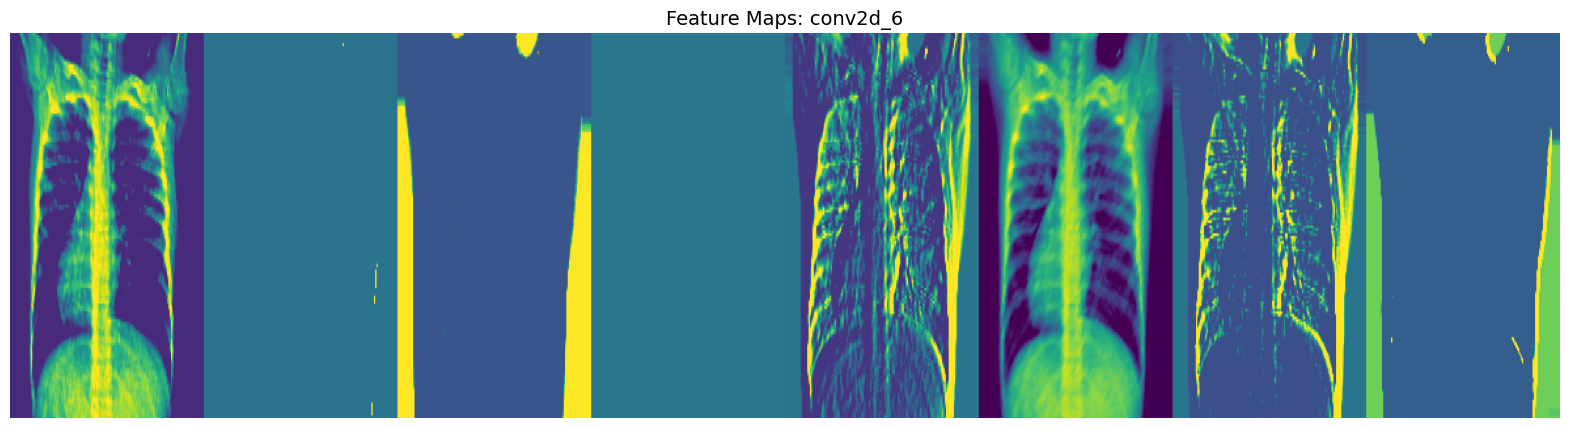

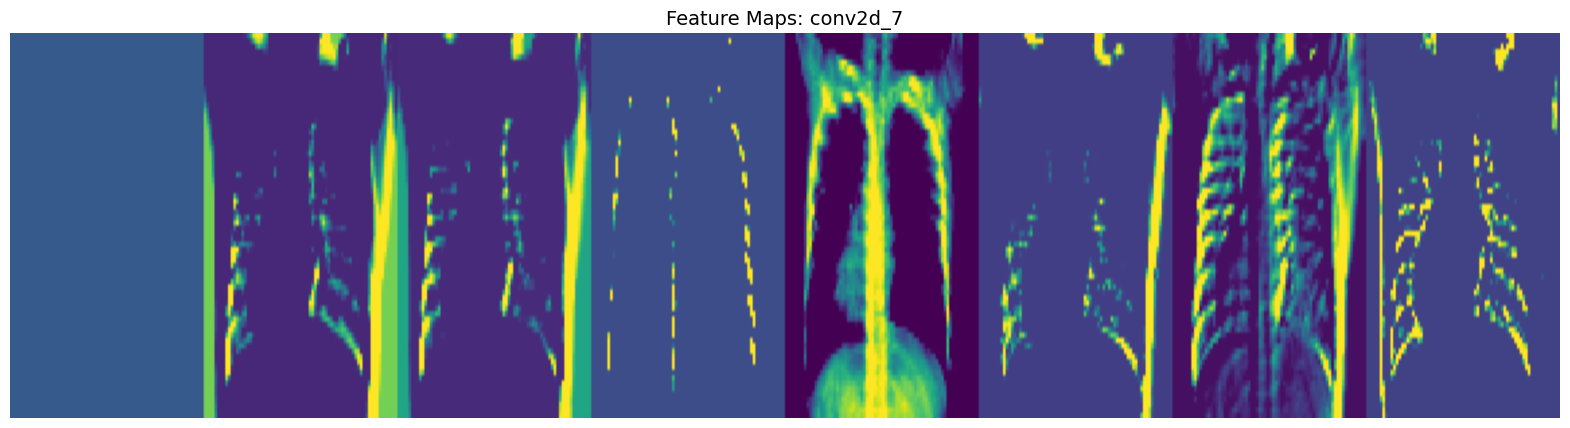

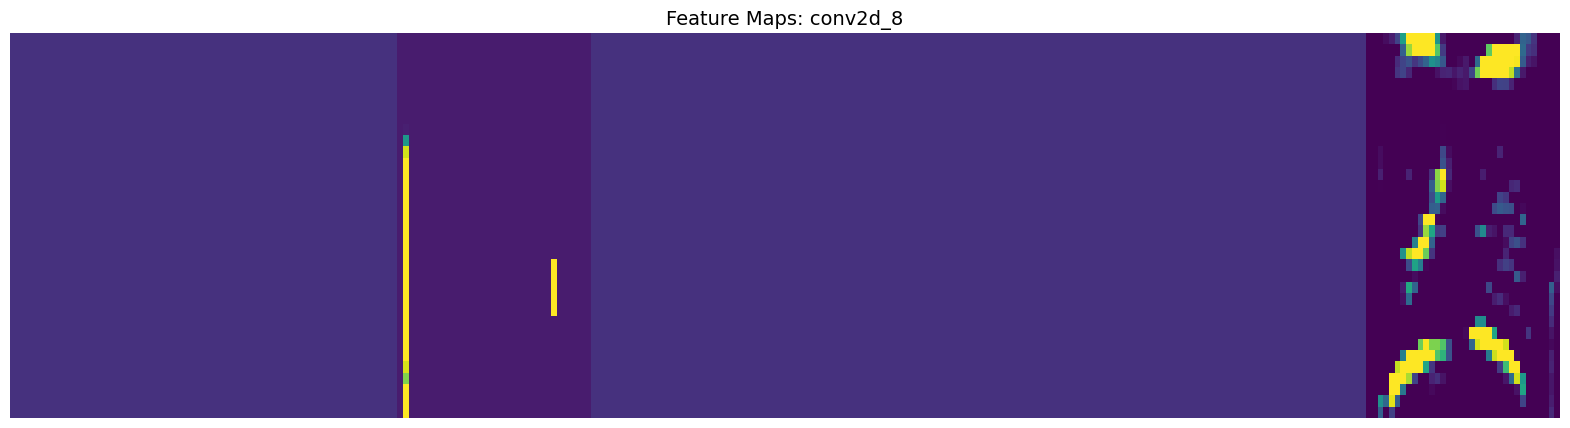

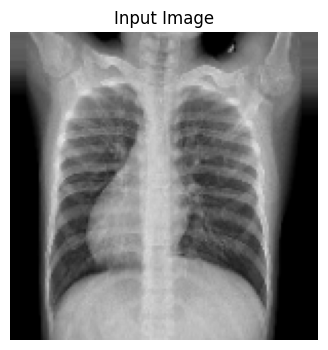

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# 1. Chuẩn bị ảnh
eval_generator.reset()
img_batch, label_batch = next(eval_generator)
sample_image = img_batch[0]
sample_image_input = np.expand_dims(sample_image, axis=0)

# 2. Định nghĩa lại mô hình phụ bằng cách tạo một Input mới hoàn toàn
# Kích thước phải khớp với đầu vào của bạn (150, 150, 3)
input_shape = (150, 150, 3)
new_input = Input(shape=input_shape)

# Chúng ta sẽ "xâu chuỗi" các lớp của mô hình gốc lại
x = new_input
layer_outputs = []
conv_layer_names = []

for layer in model.layers:
    x = layer(x) # Chạy input mới qua từng lớp của mô hình cũ
    if 'conv' in layer.name:
        layer_outputs.append(x)
        conv_layer_names.append(layer.name)

# 3. Tạo visualization_model từ Input mới và các Output đã thu thập
visualization_model = Model(inputs=new_input, outputs=layer_outputs)

# 4. Dự đoán và vẽ biểu đồ
print(f"Đang trích xuất từ các lớp: {conv_layer_names}")
feature_maps = visualization_model.predict(sample_image_input)

for layer_name, f_map in zip(conv_layer_names, feature_maps):
    n_features = f_map.shape[-1]
    size = f_map.shape[1]
    n_display = min(8, n_features)
    display_grid = np.zeros((size, size * n_display))

    for i in range(n_display):
        x_img = f_map[0, :, :, i]
        x_img -= x_img.mean()
        if x_img.std() > 0:
            x_img /= x_img.std()
        x_img *= 64
        x_img += 128
        x_img = np.clip(x_img, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = x_img

    plt.figure(figsize=(20, 5))
    plt.title(f"Feature Maps: {layer_name}", fontsize=14)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')
    plt.show()

# Ảnh gốc
plt.figure(figsize=(4, 4))
plt.title("Input Image")
plt.imshow(sample_image)
plt.axis('off')
plt.show()

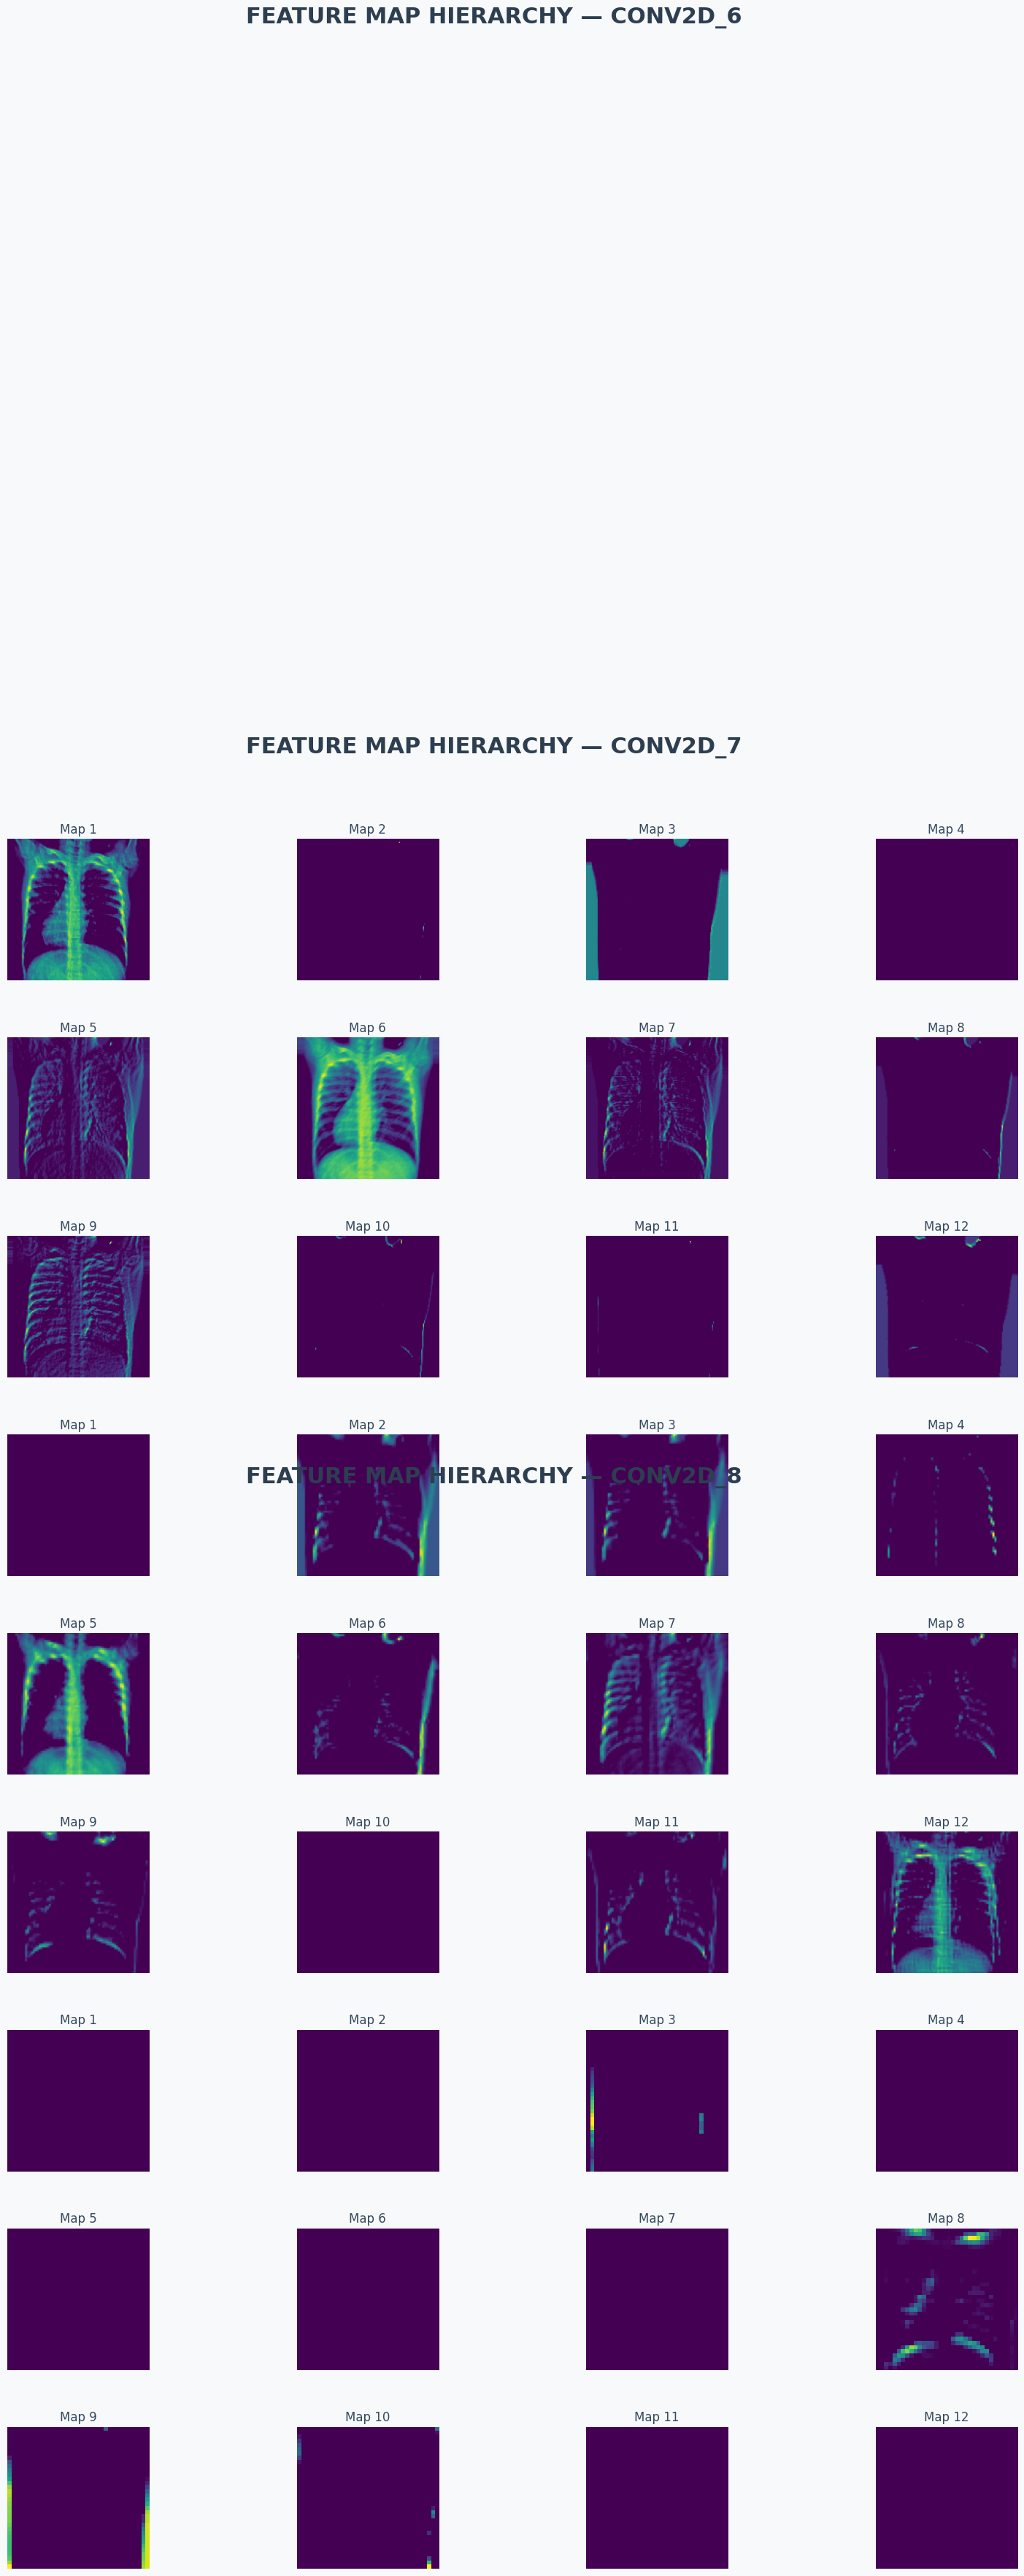

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_styled_feature_maps(feature_maps, layer_names, sample_img):
    # Số lượng lớp Conv2D
    n_layers = len(feature_maps)
    # Thiết lập số lượng filter tối đa muốn hiển thị mỗi lớp (ví dụ 12 filters để chia khung 3x4)
    n_cols = 4
    n_rows_per_layer = 3
    max_filters = n_cols * n_rows_per_layer # 12 filters

    # Tạo figure tổng với nền xám nhạt cho chuyên nghiệp
    fig = plt.figure(figsize=(20, 10 * n_layers))
    fig.patch.set_facecolor('#f8f9fa')

    for i, (f_map, name) in enumerate(zip(feature_maps, layer_names)):
        # Tạo một vùng bao quanh cho mỗi lớp (Sub-figure)
        n_filters = min(f_map.shape[-1], max_filters)

        # Tiêu đề cho từng cụm lớp
        title_y = 1.0 - (i / n_layers) - 0.02
        plt.figtext(0.5, title_y + 0.3, f"FEATURE MAP HIERARCHY — {name.upper()}",
                    ha="center", va="top", fontsize=22, fontweight='bold', color='#2c3e50')

        # Vẽ các map nhỏ
        for j in range(n_filters):
            # Tính toán vị trí subplot
            ax = fig.add_subplot(n_layers * n_rows_per_layer, n_cols, i * (n_cols * n_rows_per_layer) + j + 1)

            # Trích xuất và chuẩn hóa dữ liệu để hiển thị rõ
            fm = f_map[0, :, :, j]
            fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8) # Chuẩn hóa 0-1

            # Hiển thị với colormap viridis (như ảnh mẫu)
            ax.imshow(fm, cmap='viridis')
            ax.set_title(f"Map {j+1}", fontsize=12, color='#34495e')
            ax.axis('off')

            # Thêm khung viền màu sắc cho từng lớp (vàng, tím, xanh như ảnh mẫu)
            colors = ['#f1c40f', '#9b59b6', '#2ecc71']
            for spine in ax.spines.values():
                spine.set_edgecolor(colors[i % len(colors)])
                spine.set_linewidth(2)

    plt.subplots_adjust(hspace=0.4, wspace=0.1, top=0.9)
    plt.show()

# Gọi hàm thực hiện
# Đảm bảo bạn đã có 'feature_maps' và 'conv_layer_names' từ bước trước
plot_styled_feature_maps(feature_maps, conv_layer_names, sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


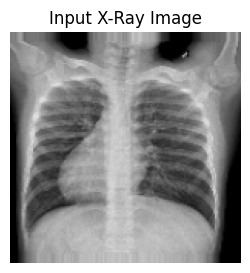

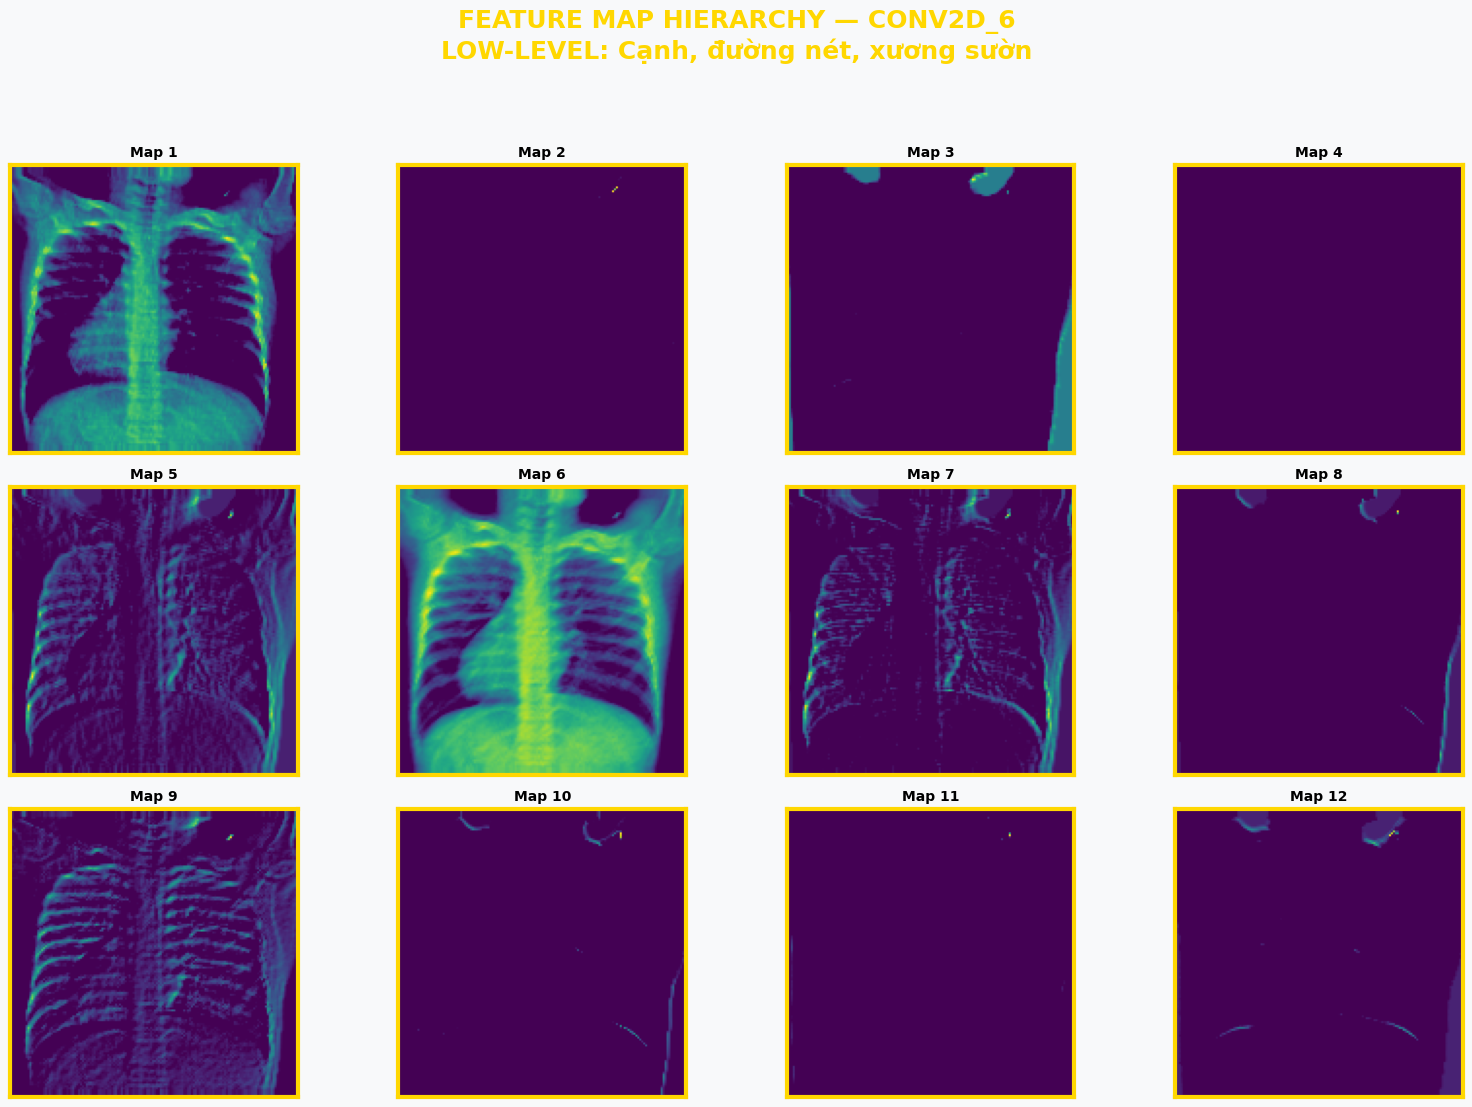

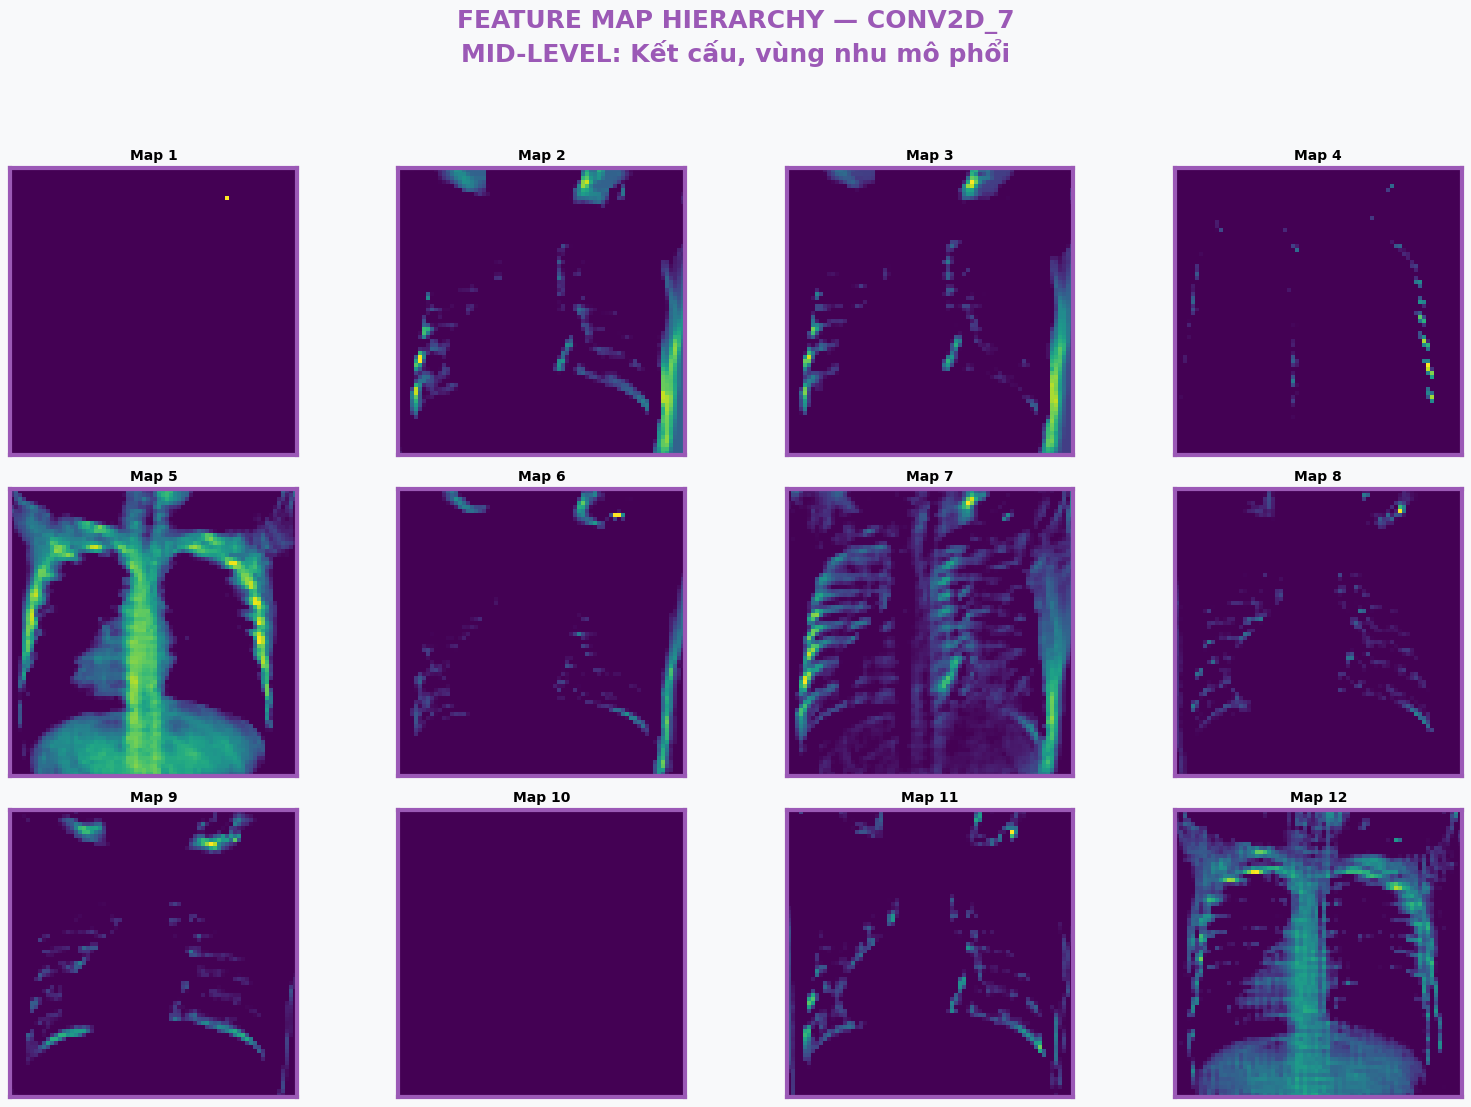

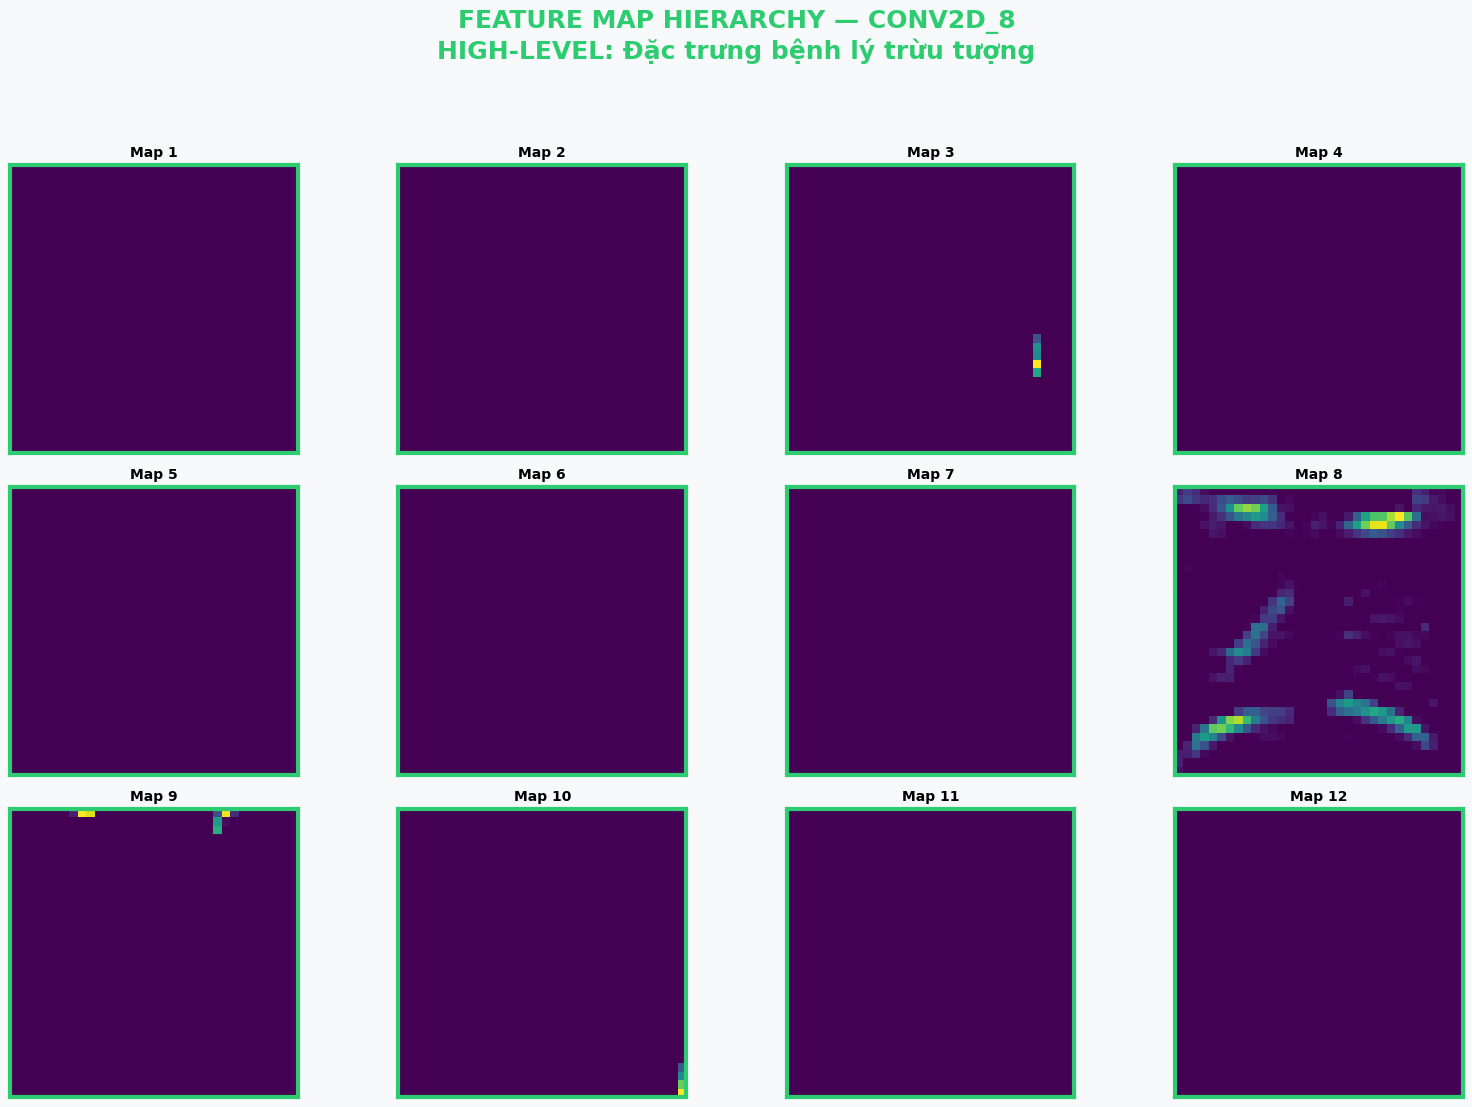

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ---
# Lấy 1 ảnh mẫu từ eval_generator (hoặc validation_generator của bạn)
eval_generator.reset()
img_batch, label_batch = next(eval_generator)
sample_img = img_batch[0]
img_tensor = np.expand_dims(sample_img, axis=0)

# --- BƯỚC 2: XÂY DỰNG MÔ HÌNH PHỤ (FIX LỖI ATTRIBUTEERROR) ---
input_shape = (150, 150, 3)
new_input = Input(shape=input_shape)
x = new_input
layer_outputs = []
conv_layer_names = []

# Duyệt qua các lớp của mô hình gốc để tái cấu trúc mô hình phụ
for layer in model.layers:
    x = layer(x)
    if 'conv' in layer.name.lower():
        layer_outputs.append(x)
        conv_layer_names.append(layer.name)

visualization_model = Model(inputs=new_input, outputs=layer_outputs)

# --- BƯỚC 3: DỰ ĐOÁN FEATURE MAPS ---
feature_maps = visualization_model.predict(img_tensor)

# --- BƯỚC 4: VẼ TRỰC QUAN HÓA THEO ĐỊNH DẠNG BÁO CÁO ---
def plot_final_feature_maps(fmaps, names, max_maps=12):
    # Cấu hình màu sắc và chú thích cho từng tầng
    colors = ['#FFD700', '#9B59B6', '#2ECC71'] # Vàng, Tím, Xanh lá
    desc = [
        "LOW-LEVEL: Cạnh, đường nét, xương sườn",
        "MID-LEVEL: Kết cấu, vùng nhu mô phổi",
        "HIGH-LEVEL: Đặc trưng bệnh lý trừu tượng"
    ]

    for i, (fmap, name) in enumerate(zip(fmaps, names)):
        n_features = min(fmap.shape[-1], max_maps)
        rows = int(np.ceil(n_features / 4))

        # Tạo khung hình cho mỗi lớp
        fig, axes = plt.subplots(rows, 4, figsize=(16, rows * 3.5))
        fig.patch.set_facecolor('#F8F9FA')

        # Tiêu đề lớn cho cụm lớp
        plt.suptitle(f"FEATURE MAP HIERARCHY — {name.upper()}\n{desc[i]}",
                     fontsize=18, fontweight='bold', color=colors[i % 3], y=1.05)

        for j in range(rows * 4):
            ax = axes.flatten()[j]
            if j < n_features:
                fm = fmap[0, :, :, j]
                # Chuẩn hóa pixel về [0, 1] để hiển thị rõ nhất
                fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)

                ax.imshow(fm, cmap='viridis')
                ax.set_title(f"Map {j+1}", fontsize=10, fontweight='bold')

                # Thêm khung viền màu sắc
                for spine in ax.spines.values():
                    spine.set_edgecolor(colors[i % 3])
                    spine.set_linewidth(3)
                    spine.set_visible(True)
            else:
                ax.axis('off') # Ẩn các ô thừa

            ax.set_xticks([])
            ax.set_yticks([])

        plt.tight_layout()
        plt.show()

# Hiển thị ảnh gốc trước
plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title("Input X-Ray Image")
plt.axis('off')
plt.show()

# Thực thi vẽ Feature Maps
plot_final_feature_maps(feature_maps, conv_layer_names)